# InsightForge

### Production-inspired Data Analytics Platform

# Import libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Load Dataset

In [40]:
DATA_DIR = Path("data")

parquet_files = list(DATA_DIR.glob("*.parquet"))

df = pd.read_parquet(parquet_files[0])

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (64403, 9)


,type,public,payload,repo,actor,org,created_at,id,other
0,ForkEvent,True,"{""forkee"":{""id"":63932764,""name"":""vcp"",""full_na...","{'id': 53594712, 'name': 'dzhelonkin/vcp', 'ur...","{'id': 5668806, 'login': 'Wushaowei001', 'grav...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-07-22 07:23:38,4312723073,"{""actor"":{""display_login"":""Wushaowei001""}}"
1,ForkEvent,True,"{""forkee"":{""id"":68070119,""name"":""moka-icon-the...","{'id': 10259527, 'name': 'snwh/moka-icon-theme...","{'id': 19811542, 'login': 'yhsilience', 'grava...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-09-13 03:17:24,4553211049,"{""actor"":{""display_login"":""yhsilience""}}"
2,ForkEvent,True,"{""forkee"":{""id"":51873866,""name"":""practice-git""...","{'id': 5518007, 'name': 'grayghostvisuals/prac...","{'id': 16548474, 'login': 'mwongka', 'gravatar...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-02-16 22:04:39,3651914491,NaN
3,ForkEvent,True,"{""forkee"":{""id"":63037882,""name"":""Flipkart_Sear...","{'id': 62739605, 'name': 'shubhamc183/Flipkart...","{'id': 13507016, 'login': 'SurenderHarsha', 'g...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-07-11 04:59:35,4258210127,"{""actor"":{""display_login"":""SurenderHarsha""}}"
4,ForkEvent,True,"{""forkee"":{""id"":63330283,""name"":""zxx.lib.css"",...","{'id': 10264058, 'name': 'zhangxinxu/zxx.lib.c...","{'id': 10969333, 'login': 'zjwzjw1018', 'grava...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-07-14 11:15:40,4277375862,"{""actor"":{""display_login"":""zjwzjw1018""}}"


# Dataset Overview

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64403 entries, 0 to 64402
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   type        64403 non-null  str           
 1   public      64403 non-null  bool          
 2   payload     64403 non-null  str           
 3   repo        64403 non-null  object        
 4   actor       64403 non-null  object        
 5   org         64403 non-null  object        
 6   created_at  64403 non-null  datetime64[us]
 7   id          64403 non-null  str           
 8   other       40189 non-null  str           
dtypes: bool(1), datetime64[us](1), object(3), str(4)
memory usage: 144.3+ MB


# Missing Values

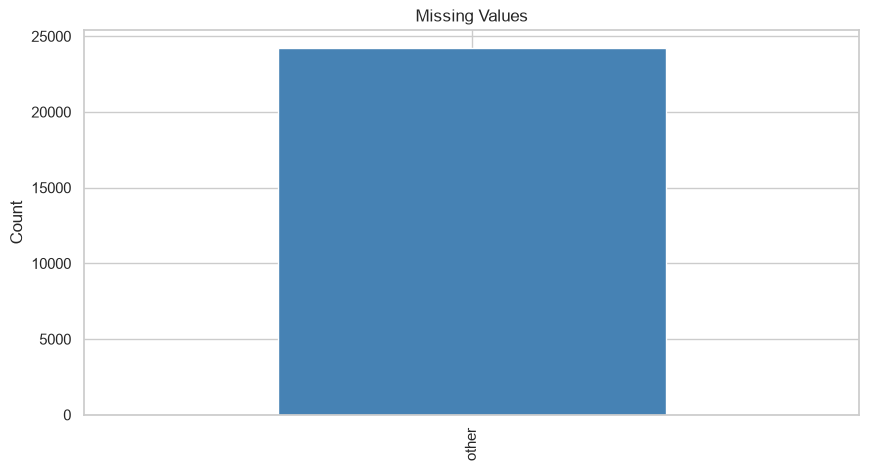

In [42]:
missing = df.isnull().sum()

missing = missing[missing > 0]

plt.figure(figsize=(10,5))

missing.sort_values().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Missing Values")

plt.ylabel("Count")

plt.show()

# Data Cleaning

In [43]:
df["created_at"] = pd.to_datetime(df["created_at"])


def nested_value(value, key):
    if isinstance(value, dict):
        return value.get(key)

    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, dict):
                return parsed.get(key)
        except:
            pass

        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, dict):
                return parsed.get(key)
        except:
            pass

    return None


df["event_type"] = df["type"]

df["repo_name"] = df["repo"].apply(lambda x: nested_value(x, "name"))

df["actor_login"] = df["actor"].apply(lambda x: nested_value(x, "login"))

rows_before = len(df)

df = df.drop_duplicates(subset=["id"])

rows_after = len(df)

print(df.shape)

(64403, 12)


# Cleaning Summary Graph

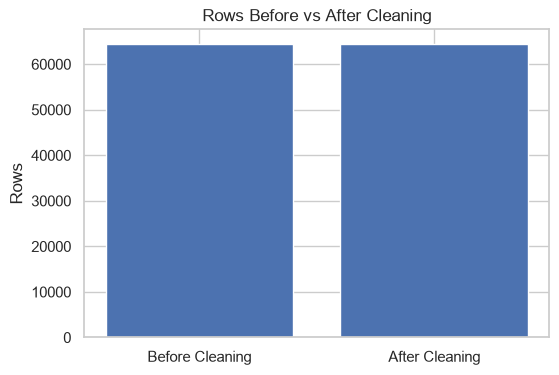

In [44]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Before Cleaning","After Cleaning"],
    [rows_before, rows_after]
)

plt.title("Rows Before vs After Cleaning")

plt.ylabel("Rows")

plt.show()

# Feature Engineering

In [45]:
df["date"] = df["created_at"].dt.date

df["month"] = df["created_at"].dt.month_name()

df["hour"] = df["created_at"].dt.hour

df["weekday"] = df["created_at"].dt.day_name()

df.head()

,type,public,payload,repo,actor,org,created_at,id,other,event_type,repo_name,actor_login,date,month,hour,weekday
0,ForkEvent,True,"{""forkee"":{""id"":63932764,""name"":""vcp"",""full_na...","{'id': 53594712, 'name': 'dzhelonkin/vcp', 'ur...","{'id': 5668806, 'login': 'Wushaowei001', 'grav...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-07-22 07:23:38,4312723073,"{""actor"":{""display_login"":""Wushaowei001""}}",ForkEvent,dzhelonkin/vcp,Wushaowei001,2016-07-22,July,7,Friday
1,ForkEvent,True,"{""forkee"":{""id"":68070119,""name"":""moka-icon-the...","{'id': 10259527, 'name': 'snwh/moka-icon-theme...","{'id': 19811542, 'login': 'yhsilience', 'grava...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-09-13 03:17:24,4553211049,"{""actor"":{""display_login"":""yhsilience""}}",ForkEvent,snwh/moka-icon-theme,yhsilience,2016-09-13,September,3,Tuesday
2,ForkEvent,True,"{""forkee"":{""id"":51873866,""name"":""practice-git""...","{'id': 5518007, 'name': 'grayghostvisuals/prac...","{'id': 16548474, 'login': 'mwongka', 'gravatar...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-02-16 22:04:39,3651914491,NaN,ForkEvent,grayghostvisuals/practice-git,mwongka,2016-02-16,February,22,Tuesday
3,ForkEvent,True,"{""forkee"":{""id"":63037882,""name"":""Flipkart_Sear...","{'id': 62739605, 'name': 'shubhamc183/Flipkart...","{'id': 13507016, 'login': 'SurenderHarsha', 'g...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-07-11 04:59:35,4258210127,"{""actor"":{""display_login"":""SurenderHarsha""}}",ForkEvent,shubhamc183/Flipkart_Search,SurenderHarsha,2016-07-11,July,4,Monday
4,ForkEvent,True,"{""forkee"":{""id"":63330283,""name"":""zxx.lib.css"",...","{'id': 10264058, 'name': 'zhangxinxu/zxx.lib.c...","{'id': 10969333, 'login': 'zjwzjw1018', 'grava...","{'id': None, 'login': None, 'gravatar_id': Non...",2016-07-14 11:15:40,4277375862,"{""actor"":{""display_login"":""zjwzjw1018""}}",ForkEvent,zhangxinxu/zxx.lib.css,zjwzjw1018,2016-07-14,July,11,Thursday


# Hourly Activity

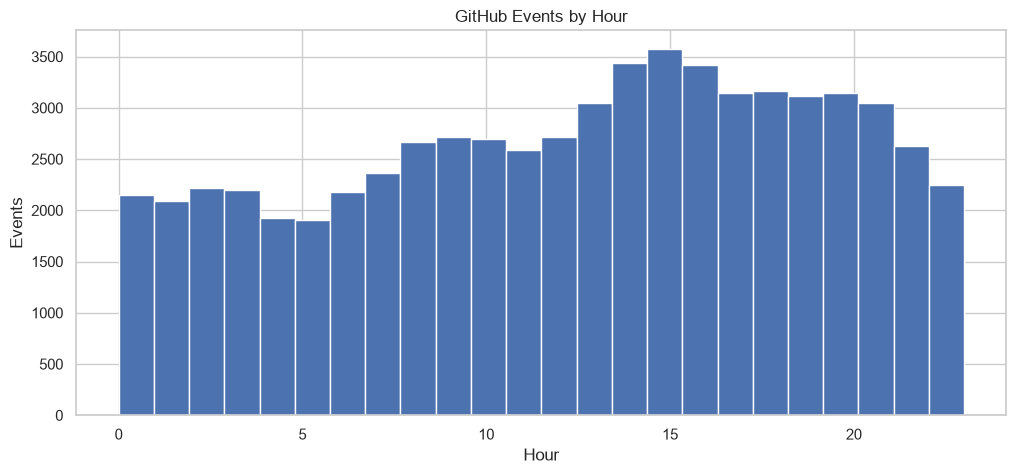

In [46]:
plt.figure(figsize=(12,5))

df["hour"].hist(bins=24)

plt.title("GitHub Events by Hour")

plt.xlabel("Hour")

plt.ylabel("Events")

plt.show()

# Business KPIs

In [47]:
print("Total Events :", len(df))

print("Repositories :", df["repo_name"].nunique())

print("Developers :", df["actor_login"].nunique())

print("Event Types :", df["event_type"].nunique())

Total Events : 64403
Repositories : 53633
Developers : 52916
Event Types : 14


# KPI Chart

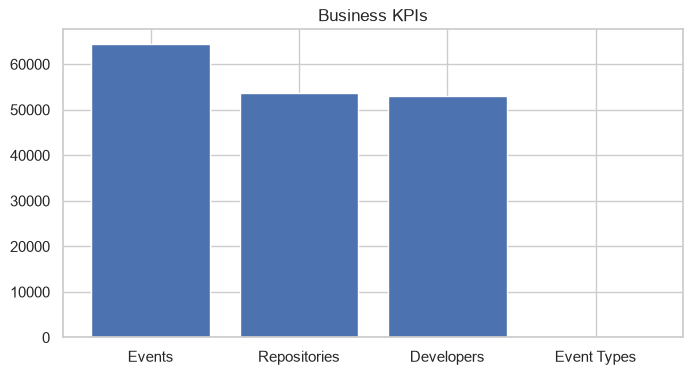

In [48]:
kpis = {

    "Events": len(df),

    "Repositories": df["repo_name"].nunique(),

    "Developers": df["actor_login"].nunique(),

    "Event Types": df["event_type"].nunique()

}

plt.figure(figsize=(8,4))

plt.bar(kpis.keys(), kpis.values())

plt.title("Business KPIs")

plt.show()

# Event Distribution

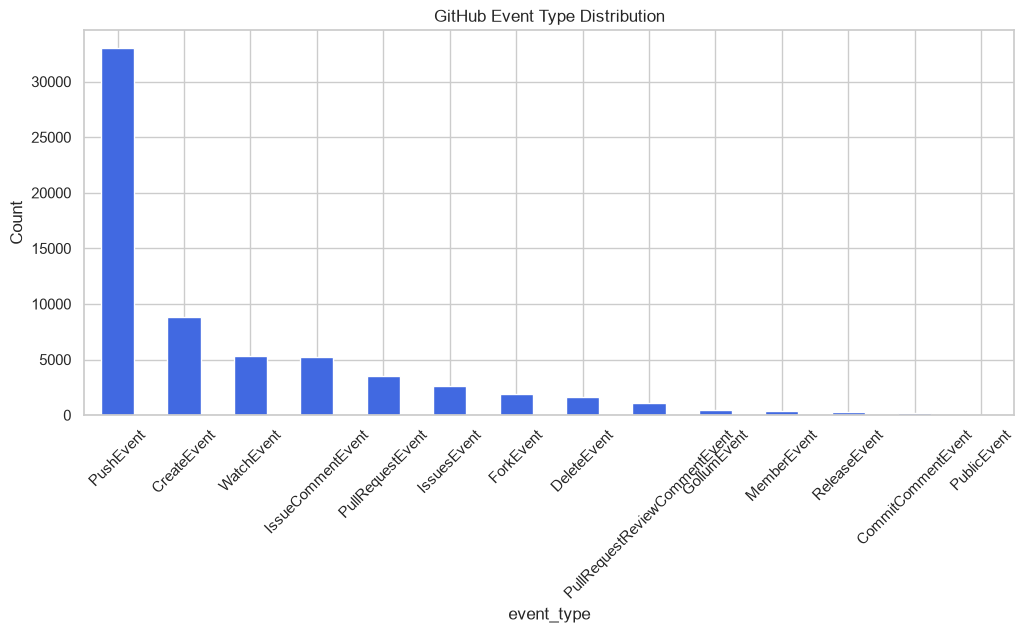

In [49]:
plt.figure(figsize=(12,5))

df["event_type"].value_counts().plot(
    kind="bar",
    color="royalblue"
)

plt.title("GitHub Event Type Distribution")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Top 10 Repositories

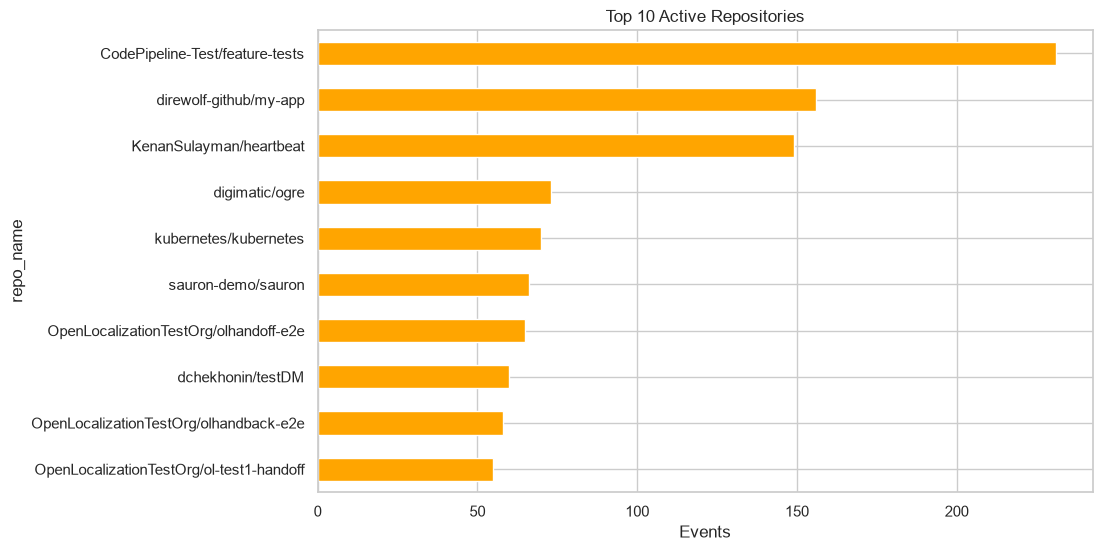

In [50]:
top_repo = df["repo_name"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_repo.sort_values().plot(
    kind="barh",
    color="orange"
)

plt.title("Top 10 Active Repositories")

plt.xlabel("Events")

plt.show()

# Top 10 Developers

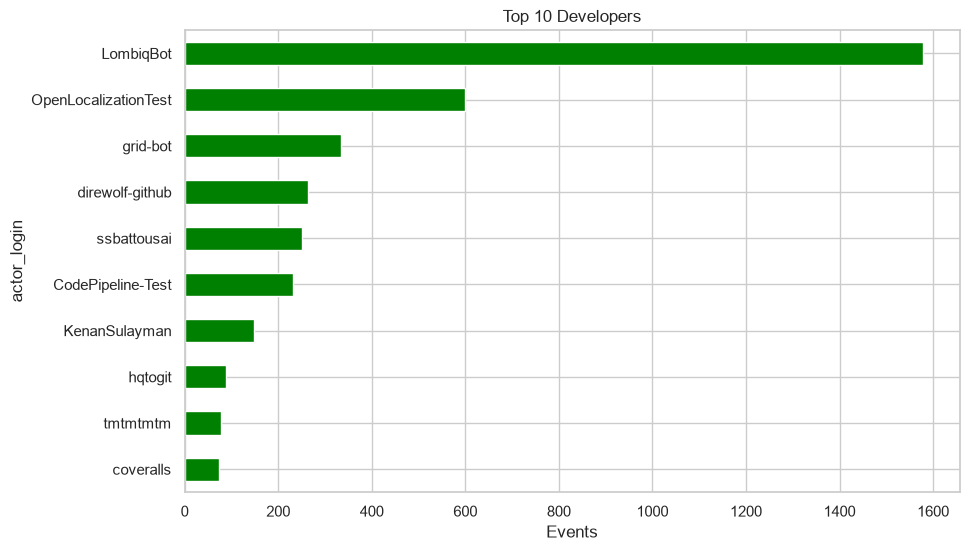

In [51]:
top_dev = df["actor_login"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_dev.sort_values().plot(
    kind="barh",
    color="green"
)

plt.title("Top 10 Developers")

plt.xlabel("Events")

plt.show()

# Daily Activity Trend

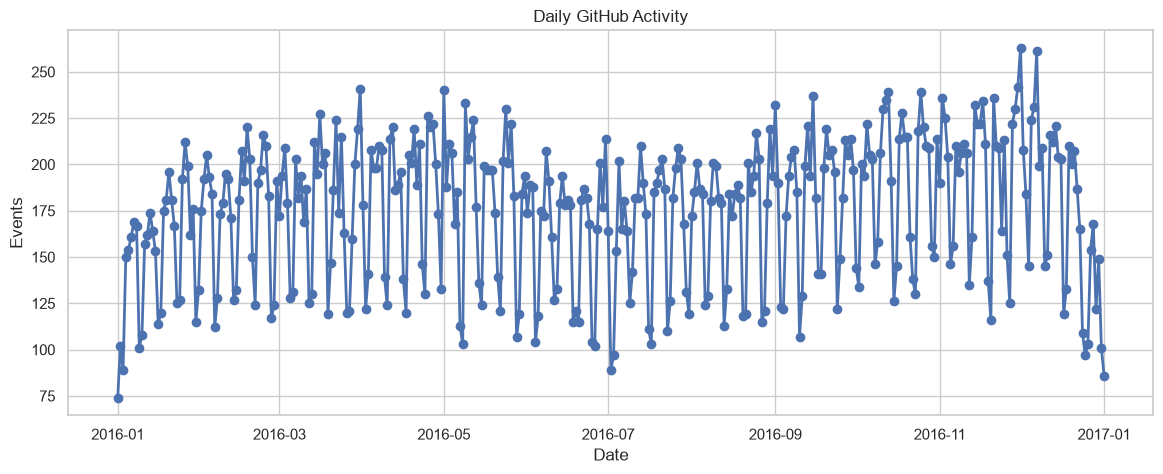

In [52]:
daily = df.groupby("date").size()

plt.figure(figsize=(14,5))

daily.plot(
    linewidth=2,
    marker="o"
)

plt.title("Daily GitHub Activity")

plt.xlabel("Date")

plt.ylabel("Events")

plt.show()

# Weekly Activity

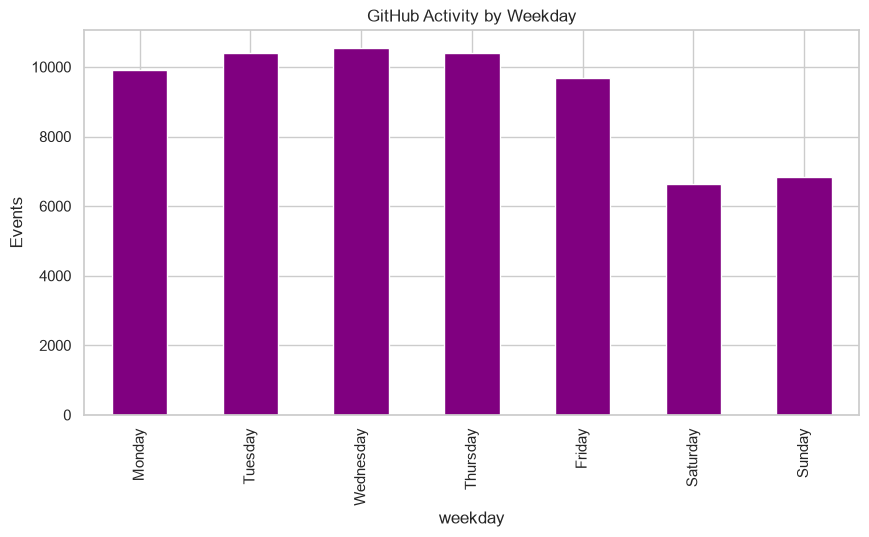

In [53]:
order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly = df["weekday"].value_counts().reindex(order)

plt.figure(figsize=(10,5))

weekly.plot(
    kind="bar",
    color="purple"
)

plt.title("GitHub Activity by Weekday")

plt.ylabel("Events")

plt.show()

# Monthly Trend

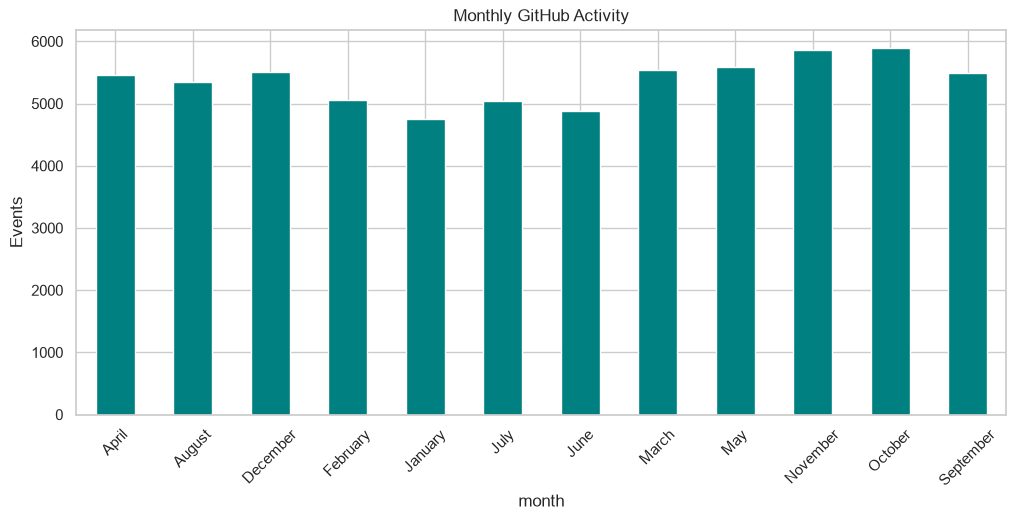

In [54]:
monthly = df.groupby("month").size()

plt.figure(figsize=(12,5))

monthly.plot(
    kind="bar",
    color="teal"
)

plt.title("Monthly GitHub Activity")

plt.ylabel("Events")

plt.xticks(rotation=45)

plt.show()

# Correlation Heatmap

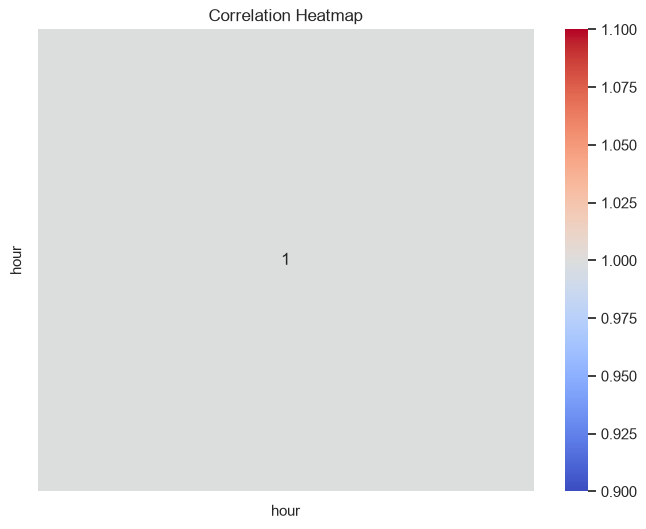

In [55]:
numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Time Series Analysis

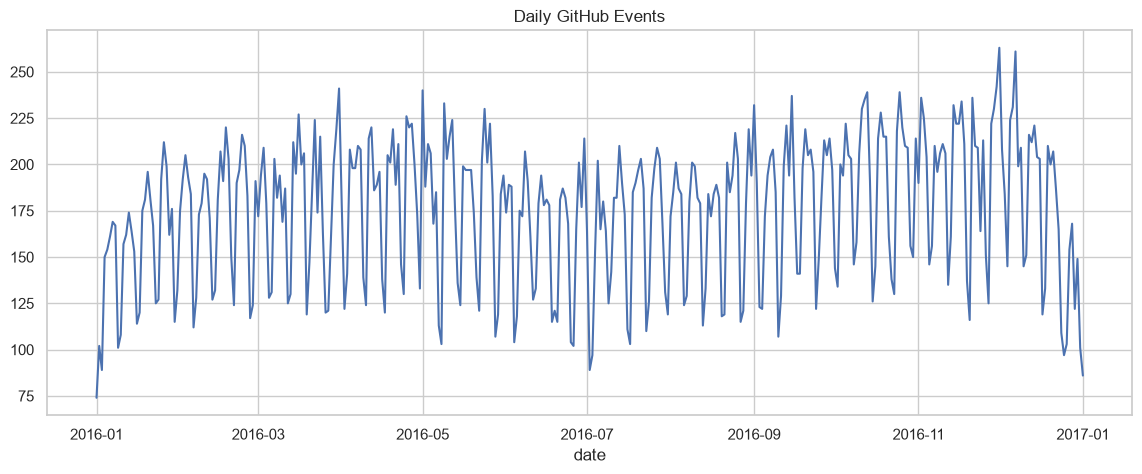

In [56]:
daily = (
    df.groupby("date")
      .size()
)

if plt is None:
    print(daily)
else:
    daily.plot(figsize=(14, 5))

    plt.title("Daily GitHub Events")

    plt.show()

# Save Clean Dataset

In [57]:
df.to_csv("clean_data.csv", index=False)

print("Clean dataset saved successfully!")

Clean dataset saved successfully!
